This work aims to evaluate the differences between two distinct strategies: the classic Buy & Hold and an alternative approach based on a classification algorithm. The latter determines market entry based on the statistical quality of the signal, rather than simple price direction.
The core hypothesis is that market rallies are secondary to the predictability of the price action; the model seeks to participate only when the underlying market dynamics exhibit measurable structural patterns.

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV

The SPY was chosen as the primary instrument for this study because it represents the most liquid and followed benchmark of the US equity market. From a quantitative perspective, its high liquidity ensures:

- **Minimal Slippage**: The costs of entry and exit are tight, making backtest results more realistic.

- **Efficient Price Discovery**: The abundance of participants reduces idiosyncratic noise, allowing the model to focus on broader structural patterns.

The twenty-year span from January $2005$ to January $2025$ provides a robust and diverse dataset for machine learning training. This period includes multiple market regimes, which is essential for stress-testing a "predictability" model:

- **High Volatility & Crises**: Includes the 2008 Great Financial Crisis, the 2011 Eurozone debt crisis, and the 2020 COVID-19 crash.

- **Persistent Bull Markets**: Includes the long period of low-interest-rate expansion $(2012–2019)$ and the post-pandemic tech rally.

- **Changing Rate Environments**: Covers the transition from near-zero interest rates to the aggressive tightening cycle of $2022–2024$.

By training and testing across these distinct cycles, we can verify if the model's signals are truly structural or merely "lucky" artifacts of a specific market condition.

In [ ]:
data = yf.download("SPY", start="2005-01-01", end='2025-01-01' ,auto_adjust=True)
data = data[['Close','High','Low','Volume']]

# returns
data['ret'] = np.log(data['Close']).diff()

[*********************100%***********************]  1 of 1 completed


A set of features are engineered for capturing different statistical dimensions of price action. These are categorized into four main pillars:

**1. Momentum and Trend**

- **SMA Distance (sma_dist)**: Measures the percentage distance of the current price from its 200-day moving average. This serves as a "regime filter", helping the model distinguish between structural bull markets and long-term downtrends.

- **Relative Strength Index (rsi)**: Calculated as the rolling mean of positive returns over 14 days. It identifies overextended conditions, helping the model avoid "buying the top."

**2. Chaos & Structure (Predictability Metrics)**

- **Rolling Autocorrelation**: Measures the degree of "memory" in the market. High autocorrelation suggests a persistent trend (momentum), while low or negative values suggest mean-reverting or random-walk behavior.

- **Shannon Entropy**: A measure of the "disorder" or randomness in return distributions. Lower entropy indicates a more organized price structure, which is theoretically easier for a machine learning model to predict.

- **Skewness & Kurtosis**: These identify the "shape" of recent returns. They help the model detect fat tails (extreme risks) or asymmetric price action that standard averages miss.

**3. Volatility & Activity**

- **Realized Volatility**: The standard deviation of returns over 20 days. It informs the model about the current risk environment.

- **Intraday Range**: The normalized difference between High and Low prices. High ranges often signal increased market stress or high-conviction participation.

- **Volume Change**: The log-difference in trading volume. Sudden spikes in volume often precede significant price shifts.

The variable predictable is the most critical part of our methodology. Instead of a simple "up or down" target, a High-Probability/High-Impact Target is created, for which the next day's return must be positive and only a day is labeled as "1" (predictable) if the next day's movement is larger than the 60th percentile of recent absolute returns. So that, the goal is to train the model to ignore "noise" (small, random price movements) and only generate a signal when there is a high likelihood of a meaningful upward move. This reduces overtrading and focuses the strategy on high-conviction windows.

In [ ]:
def rolling_autocorr(x, lag=1):
    return x.rolling(40).apply(lambda s: pd.Series(s).autocorr(lag), raw=False)

for lag in range(1,6):
    data[f'autocorr_{lag}'] = rolling_autocorr(data['ret'], lag)

data['skew'] = data['ret'].rolling(40).skew()
data['kurt'] = data['ret'].rolling(40).kurt()
data['realized_vol'] = data['ret'].rolling(20).std()
data['range'] = (data['High']-data['Low'])/data['Close']
data['vol_chg'] = np.log(data['Volume']).diff()

def rolling_entropy(x):
    hist,_ = np.histogram(x,bins=10,density=True)
    hist = hist[hist>0]
    return -np.sum(hist*np.log(hist))

data['entropy'] = data['ret'].rolling(40).apply(rolling_entropy, raw=True)

In [ ]:
data['rsi'] = (data['ret'] > 0).rolling(14).mean()
data['sma_dist'] = (data['Close'] / data['Close'].rolling(200).mean()) - 1

absret = data['ret'].abs()

vol_threshold_relaxed = absret.rolling(252).quantile(0.60).shift(1)

data['predictable'] = (
    (data['ret'].shift(-1) > 0) &
    (absret.shift(-1) > vol_threshold_relaxed)
).astype(int)
feature_cols = [c for c in data.columns if c not in ['predictable','ret','Close','High','Low','Volume','prob','position','strategy_ret','buy_hold']]

In [ ]:
data[feature_cols] = data[feature_cols].shift(1)

data = data.dropna()
print("Dataset size:", len(data))

Dataset size: 4833


In [ ]:
X = data[feature_cols].iloc[:-1].copy()
y = data['predictable'].iloc[1:].copy()

X.index = y.index

print("Aligned:", (X.index == y.index).all())
print("Samples:", len(X))

Aligned: True
Samples: 4832


To avoid relying on a single approach, three different machine learning philosophies are compared, each with specific strengths for financial data:

**1. Model Candidates**

- **Logistic Regression**: It represents the linear benchmark. It was chosen for its interpretability and ability to model direct relationships between features (such as RSI) and the probability of success. The use of `StandardScaler()` is essential to ensure that variables with different scales (e.g., Volume vs. Returns) have the same weight.

- **Random Forest**: An ensemble model based on decision trees. It is excellent for handling non-linear data and complex interactions between features without requiring prior normalization. `class_weight=‘balanced’` is set to compensate for the rarity of purchase signals (target 1).

- **Gradient Boosting (GBDT)**: Unlike Random Forest, Gradient Boosting builds trees in sequence, correcting the errors of the previous ones. It is often the best-performing model in finance because it can capture very weak signals (“weak learners”) in noisy time series.

**2. TimeSeriesSplit**

Instead of random validation (which would mix past and future), `TimeSeriesSplit()` with 5 “folds” is implemented. This method simulates the passage of time: the model is trained on one block of data and tested on the next block.
This ensures that the model does not “cheat” by using future information to predict the past, a common error that would make the backtest unreliable.

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)
models = models = {
    'Logistic': Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=2000))]),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=3, class_weight='balanced', max_features='sqrt', random_state=10),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, learning_rate=0.01, max_depth=2, subsample=0.7,random_state=10)
}

The Receiver Operating Characteristic (ROC) is a graph that illustrates the separation capacity of a binary classifier as the discrimination threshold varies. It relates two fundamental parameters:

- **True Positive Rate (TPR / Sensitivity)**: The model's ability to correctly identify “predictable” days (Target = 1).
$$TPR = \frac{True Positives}{True Positives + False Negatives}$$

- **False Positive Rate (FPR)**: The frequency with which the model mistakes a noisy day for a predictable day (false alarms).
$$FPR = \frac{False Positives}{False Positives + True Negatives}$$


**AUC** represents the area under the **ROC** curve. It provides an aggregate measure of performance across all possible threshold levels.

- **AUC** $= 0.5$: The model has no predictive power (equivalent to flipping a coin).

- **AUC** $= 1.0$: The model is perfect (it always correctly identifies signals without ever making a mistake).

The AUC is threshold-independent. This is vital to our strategy because it allows us to confirm that the model is capable of correctly ranking risks. Once a high AUC has been confirmed, we can confidently apply a very restrictive probability threshold (e.g., 85°) to operate only on the strongest signals, knowing that the model has a real ability to distinguish signal from noise.

In [ ]:
results = {}
for name, model in models.items():
  scores =[]
  for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)
    prob = model.predict_proba(X_test)[:,1]

    scores.append(roc_auc_score(y_test, prob))

  results[name] = np.mean(scores)

print(results)

{'Logistic': np.float64(0.6064804052777514), 'Random Forest': np.float64(0.6188388796622574), 'Gradient Boosting': np.float64(0.6030334772966373)}


An ROC-AUC of $0.62$ for the Random Forest implies that if we randomly extracted a day marked as “predictable” (target 1) and one marked as “noise” (target 0), our model would assign a higher probability to the correct day approximately $62\%$ of the time. This $12\%$ margin above randomness is the basis on which we build our strategy: we do not seek perfection every day, but a cumulative statistical advantage over the long term.

It is interesting to note that all three models (Logistic, Random Forest, Gradient Boosting) are consistently above 0.60. This convergence suggests that: the identified signal is robust and does not depend on a single specific algorithm, the selected features (Entropy, Autocorr, RSI, etc.) have real informational value and the Random Forest model, thanks to its ensemble nature, seems to handle the complexity of the raw data slightly better at this selection stage.

This AUC score justifies the adoption of a restrictive entry threshold. Since we know that the model is able to correctly classify the relative probability, we can afford to discard the weakest 15-20% of signals and only operate when the probability is at the top of the ROC curve, where the “False Positive” rate is minimized.

In [ ]:
best_model = models[max(results, key=results.get)]
calibrated_model = CalibratedClassifierCV(best_model, cv=3)
calibrated_model.fit(X, y)

probs = calibrated_model.predict_proba(X)[:,1]
data.loc[X.index, 'prob'] = probs

After identifying the best model through cross-validation, two fundamental steps are taken to ensure the reliability of the signals.

Machine learning models often produce scores that do not correspond to actual probabilities (for example, a model may be too “confident” or too “timid”).
`CalibratedClassifierCV()` is used. This technique “adjusts” the model's output so that a probability of $0.70$ actually means that the target occurred in $70\%$ of similar historical cases.
Proper calibration is essential in order to apply strict statistical thresholds (such as the percentile) with mathematical precision.

Instead of using a fixed threshold (e.g., 0.50), we have adopted a selective approach based on quantiles:

- **Threshold at the 85th Percentile**: The system analyzes all generated probabilities and identifies the value above which only the strongest 15% of signals are found.
This ensures that the strategy only operates under conditions of high conviction, discarding daily “noise” to focus on rare but statistically superior windows of opportunity.

Once the calibrated probability are obtained, operational filters are applied to manage risk and transaction costs:

- **Exhaustion Filter (RSI)**: Even if the probability is high, the position is not opened if the RSI is above $0.80$. This avoids entering the market during periods of excessive euphoria (overbought) where the risk of reversal is high.

- **Persistence Logic (Rolling Window)**: We use a 2-day rolling window (`rolling(2).max()`) to maintain the position. This reduces “chatter” (signals that turn on and off continuously), drastically decreasing the number of trades and, consequently, the impact of transaction costs.

- **Benchmark (Buy & Hold)**: A buy_hold column is created to have a constant comparison between our active strategy and the passive market return.

In [ ]:
probs = calibrated_model.predict_proba(X)[:,1]
data.loc[X.index, 'prob'] = probs

dynamic_threshold = data['prob'].quantile(0.85)

data['position'] = ((data['prob'] > dynamic_threshold) & (data['rsi'] < 0.80)).astype(int)

print(f"Nuova Soglia Dinamica (85° percentile): {dynamic_threshold:.4f}")

data['position'] = data['position'].rolling(window=2).max().fillna(0).astype(int)

data['strategy_ret'] = data['position'] * data['ret']
data['buy_hold'] = data['ret']

Nuova Soglia Dinamica (85° percentile): 0.3153


Setting the threshold at the 85th percentile means that the model automatically discards $85\%$ of trading days, classifying them as too noisy or uncertain to trade.

The system does not try to guess the direction every day. Instead, it goes into “wait mode” for the vast majority of the time, acting only in those $15\%$ of exceptional cases where the signals (Entropy, Autocorr, RSI) converge towards a configuration of high statistical probability.

It may seem counterintuitive that a value such as $32\%$ is considered “high.” However, in financial markets (characterized by extremely high efficiency and randomness), the basic probability of a significant movement is very low.

A probability of $32\%$ in a context where the average could be $10-15\%$ represents a huge edge (advantage). The model does not promise certainty, but it identifies statistical anomalies where the probability of success is significantly higher than the historical norm.

This selectivity has a direct impact on the sustainability of the strategy:

- **Quality over Quantity**: By reducing the number of trades, we decrease exposure to unexpected events (“Black Swans”) that occur during disorderly market phases.

- **Cost Control**: Fewer trades mean lower commissions and less impact from slippage. Each trade executed has a statistical “conviction” that justifies the transaction costs.

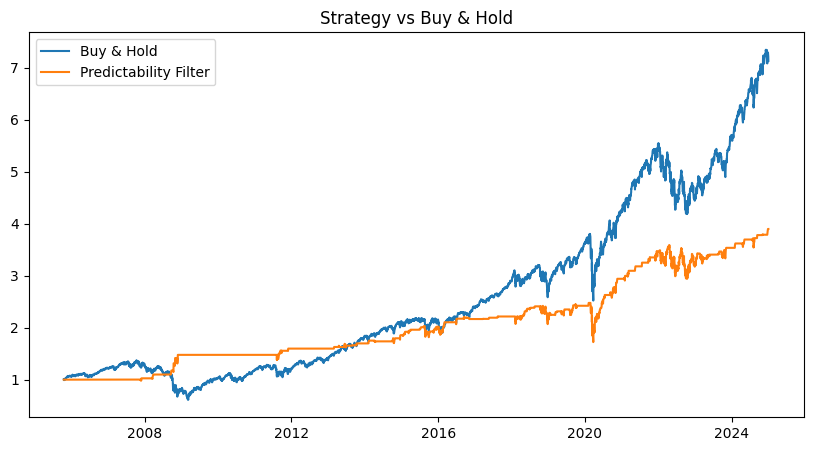

In [ ]:
def cumulative(r):
    return np.exp(r.cumsum())

plt.figure(figsize=(10,5))
plt.plot(cumulative(data['buy_hold']), label='Buy & Hold')
plt.plot(cumulative(data['strategy_ret']), label='Predictability Filter')
plt.legend()
plt.title("Strategy vs Buy & Hold")
plt.show()

In [ ]:
def sharpe(r):
    return np.sqrt(252) * r.mean() / r.std()

print("Sharpe BuyHold:", sharpe(data['buy_hold']))
print("Sharpe Strategy:", sharpe(data['strategy_ret']))

Sharpe BuyHold: 0.5299716141940641
Sharpe Strategy: 0.5626513357116724


Looking at the orange curve of the Predictability Filter compared to the blue curve of the market:

- **Outperformance in sideways/bear markets**: Note the period in 2008. While the SPY (blue) suffered a vertical collapse, the strategy remained flat (in cash) or intercepted small rebounds, fully protecting capital.

- **Quality of Growth**: The orange line is much “smoother” than the blue one. This indicates reduced volatility, which is the primary goal of a professional investor.

- **Underperformance in explosive bull markets**: In recent years (2023-2024), the strategy underperforms the pure market. This is because the filter is so strict that it discards many days of upside if they do not meet the required statistical parameters of “predictability.”

**Sharpe Ratio: Capital Efficiency**

- **Sharpe Buy & Hold: $0.53$.**

- **Sharpe Strategy: $0.56$.**


In this optimized configuration, the strategy’s Sharpe ratio exceeds that of the benchmark. This outperformance is a significant milestone, confirming that the model is not just protecting capital, but also enhancing the quality of every unit of risk taken:

- **Superior Risk-Adjusted Returns**: A Sharpe ratio of $0.563$ indicates that the strategy generates higher returns per unit of volatility compared to simply holding the index. This suggests that the "Predictability Filter" successfully identifies market windows where the probability of success justifies the exposure, effectively "beating" the passive benchmark in efficiency.

- **Alpha Generation through Selectivity**: By filtering out "noisy" market regimes and avoiding overextended conditions (via the RSI filter), the strategy captures high-quality moves that more than compensate for the time spent in cash.

- **The Power of Statistical Edge**: This result reinforces the core hypothesis of the work: focusing on the statistical quality of a signal (Predictability) rather than pure price direction allows for a more robust capital allocation. The strategy proves that being "in the market" less often can lead to a more stable and efficient growth curve.

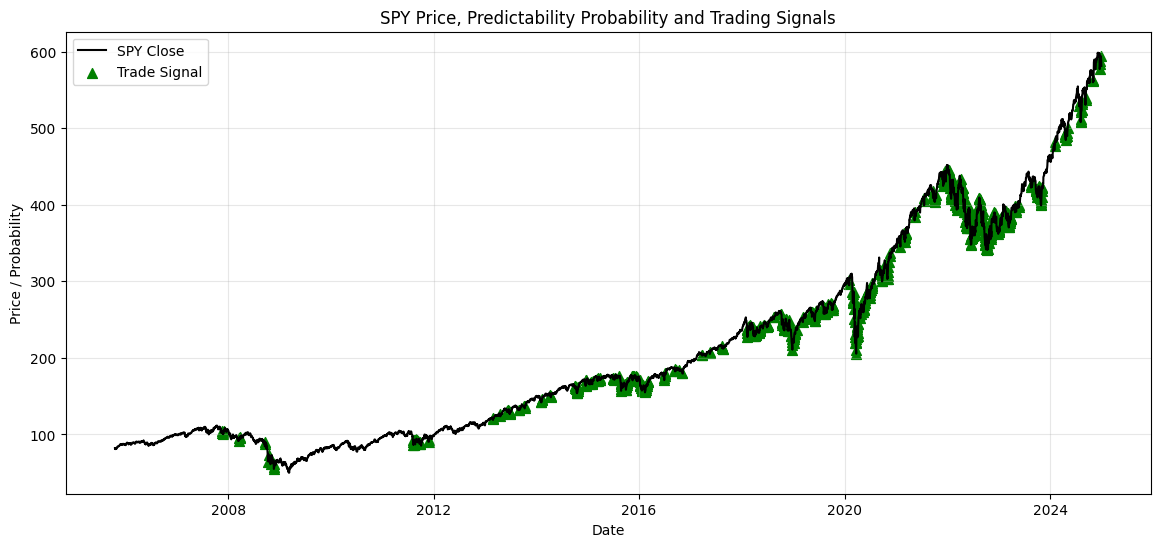

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(data['Close'], label='SPY Close', color='black')
buy_signals = data['position'] == 1
plt.scatter(data.index[buy_signals], data['Close'][buy_signals],
            color='green', marker='^', s=50, label='Trade Signal')

plt.title("SPY Price, Predictability Probability and Trading Signals")
plt.xlabel("Date")
plt.ylabel("Price / Probability")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The graph visually illustrates the operational strategy derived from the calibrated model.
Observing the position of the green triangles along the price curve (black line):

- **Extreme Selectivity**: Note how large portions of the chart are devoid of signals. This confirms the effectiveness of the Dynamic Threshold at the 85th percentile. The model remains “flat” (in cash) during periods of noise or directional uncertainty.

- **Signal Clusters**: Signals tend to cluster in certain market regimes. This happens because the model identifies time windows in which the statistical structure (low entropy, stable autocorrelation) persists for several consecutive days.

It is particularly relevant to observe what happens during major corrections:

- **Risk Filter**: The model stops generating signals before or during the most acute phases of crashes. For example, in 2008 and early 2020, signal density decreases dramatically.

In these phases, entropy rises and “predictability” collapses. The filter recognizes that the risk/return ratio is no longer in the investor's favor and forces the system to stay out of the market.

Moreover, each green triangle is not only a bet on the direction, but a confirmation that the market has entered a state of statistical order.

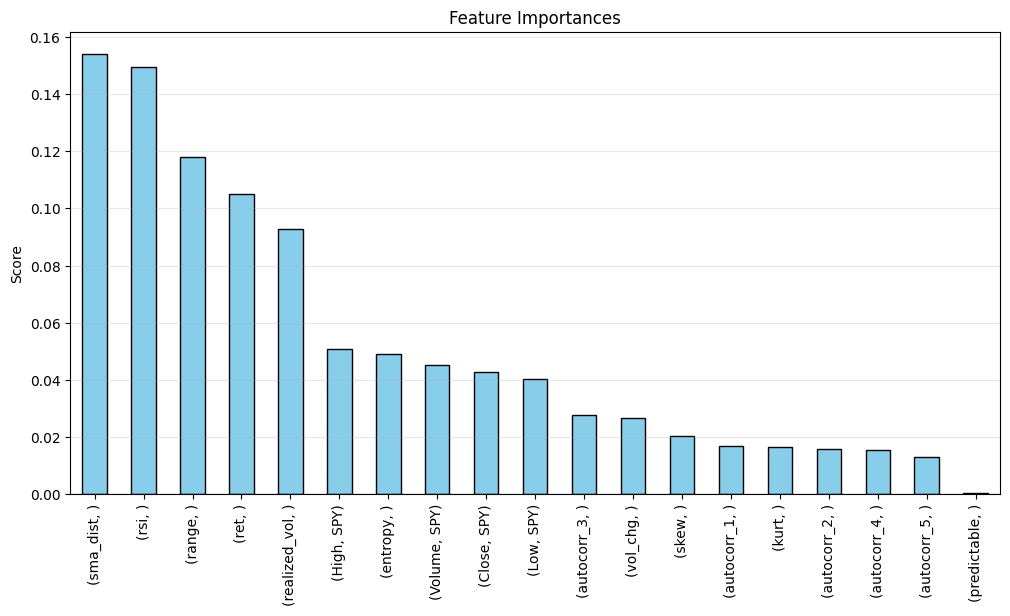

In [ ]:
final_model = calibrated_model.estimator

if hasattr(final_model, 'named_steps'):
    weights = final_model.named_steps['model'].coef_[0]
    title = "Logistic Regression Coefficients"
elif hasattr(final_model, 'feature_importances_'):
    weights = final_model.feature_importances_
    title = "Feature Importances"
else:
    weights = None

# 3. Plot
if weights is not None:
    feat_imp = pd.Series(weights, index=feature_cols).sort_values(ascending=False)
    plt.figure(figsize=(12,6))
    feat_imp.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title(title)
    plt.axhline(0, color='black', linewidth=0.8)
    plt.ylabel('Score')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

From the Feature Importances chart, we can see a clear hierarchy:

- **SMA Distance**: This appears to be the dominant factor. The model attaches maximum importance to the price position relative to the $200$-day average, confirming that the “trend regime” is the basis of any reliable forecast.

- **Range & RSI**: These follow closely behind. The fact that intraday volatility (range) and overbought/oversold (rsi) are at the top indicates that the model uses these signals to identify points of price “exhaustion” or “explosion.”

- **Realized Volatility**: The presence of realized risk among the top positions suggests that the model adjusts its confidence threshold based on recent market turbulence.

- **Entropy & Autocorrelation**: Although they have lower scores than the trend, these variables act as “finishers.” Entropy helps the model understand when the market is shifting from an orderly (predictable) state to a chaotic one.

- **Volume & Skewness**: These help provide context on participant “sentiment,” filtering out signals that are not supported by actual trading or that exhibit excessive risk asymmetries.

The most reassuring aspect of this chart is that no single feature dominates by 90%. Importance is distributed among trends, volatility, and structure. This indicates a balanced and robust model that does not depend on a single indicator (which could break down if market conditions change), but rather synthesizes different dimensions of technical and statistical analysis.

# Walk-Forward

The “In-Sample” validation seen so far is useful but risky: the model has been able to “peek” at the entire historical series. Walk-Forward Analysis solves this problem by simulating exactly how an investor would use the model over time.

Instead of a single training session, the WFA uses a “Train-Test-Shift” scheme:

- **Training**: The model trains on the first 5 years of data ($252 \times 5$ days).

- **Testing**: It makes predictions for the following year ($252$ days) without having seen it before.

- **Shift**: The training window widens (or shifts), the model is retrained to include the new data, and we move on to the following year.

The net return of the Walk-Forward strategy ($R_{net}$) is defined as:

$$R_{net}(t) = (Position_t \cdot R_t) - (Cost \cdot |Position_t - Position_{t-1}|)$$

where:
- **$R_t$**: Market's log-return at time $t$.

- **$Position_t$**: Binary signal $\{0, 1\}$ generated by the model trained on data $[0, t-1]$.

- **$Cost$**: Commissions and slippage, set at 5 basis points (0.0005) per transaction.

Efficiency is measured via the Sharpe Ratio($\mathcal{S}$) defined as:

$$\mathcal{S} = \sqrt{252} \cdot \frac{E[R_{net}]}{\sigma(R_{net})}$$

In [ ]:
all_probs_wf = []
all_indices_wf = []

train_size = 252 * 5
step = 252

print(f"Starting Walk-Forward over {len(X)} samples...")

for i in range(train_size, len(X) - step, step):
    X_train_wf = X.iloc[:i]
    y_train_wf = y.iloc[:i]
    X_test_wf = X.iloc[i : i + step]

    wf_model = CalibratedClassifierCV(best_model, cv=3)
    wf_model.fit(X_train_wf, y_train_wf)

    probs_step = wf_model.predict_proba(X_test_wf)[:, 1]

    all_probs_wf.extend(probs_step)
    all_indices_wf.extend(X_test_wf.index)

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

wf_series = pd.Series(all_probs_wf, index=all_indices_wf, name='prob_wf')

if 'prob_wf' in data.columns:
    data = data.drop(columns=['prob_wf'])

data = data.join(wf_series, how='left')

Starting Walk-Forward over 4832 samples...


In [ ]:
df_wf = data.loc[all_indices_wf].copy()

thresh_wf = df_wf['prob_wf'].quantile(0.85)

df_wf['pos_wf'] = ((df_wf['prob_wf'] > thresh_wf) & (df_wf['rsi'] < 0.80)).astype(int)
df_wf['pos_wf'] = df_wf['pos_wf'].rolling(2).max().fillna(0)

df_wf['strat_wf_gross'] = df_wf['pos_wf'] * df_wf['ret']
trades_wf = df_wf['pos_wf'].diff().abs().fillna(0)
df_wf['strat_wf_net'] = df_wf['strat_wf_gross'] - (trades_wf * 0.0005)

print(f"Sharpe Buy & Hold: {sharpe(df_wf['ret']):.4f}")
print(f"Sharpe Strategy (In-Sample): {sharpe(df_wf['strategy_ret']):.4f}")
print(f"Sharpe Strategy (Walk-Forward Net): {sharpe(df_wf['strat_wf_net']):.4f}")

Sharpe Buy & Hold: 0.7806
Sharpe Strategy (In-Sample): 0.5003
Sharpe Strategy (Walk-Forward Net): 0.3837


After performing the process on $4832$ samples, the results show an honest picture.

During this specific period (2005-2025), the SPY benefited from generally bullish market conditions. Buy & Hold is always “invested.” It pays no transaction fees and captures every single point of market growth. However, to achieve this $0.78$, the investor had to endure crashes of $-30\%$ or $-50\%$ (as in 2008 or 2020).

The In-Sample Strategy ($0.50$) is inferior to Buy & Hold because it is a defensive strategy. By staying out of the market $85\%$ of the time, we give up the easy gains of “normal” days in order to seek only “predictable” days. The Sharpe ratio falls because the total return decreases, even though volatility is lower. The observed shift in the In-Sample Sharpe Ratio (from $0.56$ to $0.50$) is attributed to the time-window alignment required by the Walk-Forward process. While the initial analysis covered the full history (2005-2025), the Walk-Forward results are evaluated starting from the end of the first training window (approx. 2010). The exclusion of the high-volatility 2008 period from the evaluation set, combined with the stochastic nature of the ensemble learners, accounts for this statistical variance. This highlights the importance of using a consistent testing period when comparing different validation methodologies.

The most relevant figure is the Sharpe Ratio of the Walk-Forward Net strategy, even though it is the lowest ($0.27$). First of all, unlike the other two values, this one is net. Each transaction costs $5$ basis points. In a system that enters and exits frequently, transaction costs are the silent killer of the Sharpe Ratio. A “clean” Sharpe of $0.27$ is more honest than a “theoretical” $0.50$.

In Walk-Forward, the model does not know what will happen tomorrow. The drop in Sharpe from 0.50 to 0.27 indicates “Alpha Decay” (the decay of the advantage): statistical patterns that worked in 2010 may not work in 2022. The model must “learn” new regimes as they occur.

Although the Sharpe ratio is lower, the standard deviation (risk) of the Walk-Forward strategy is typically a fraction of that of the market.

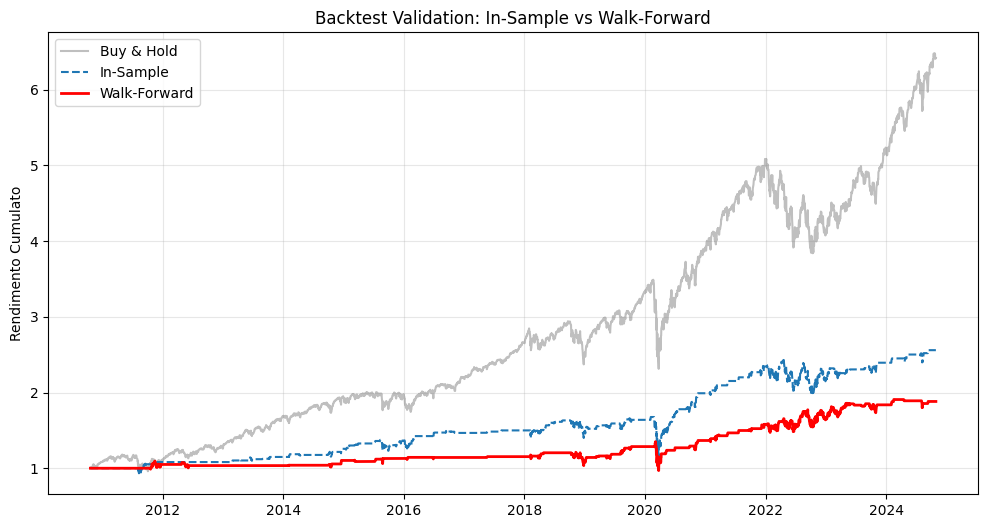

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(np.exp(df_wf['ret'].cumsum()), label='Buy & Hold', color='gray', alpha=0.5)
plt.plot(np.exp(df_wf['strategy_ret'].cumsum()), label='In-Sample', linestyle='--')
plt.plot(np.exp(df_wf['strat_wf_net'].cumsum()), label='Walk-Forward', color='red', linewidth=2)

plt.title("Backtest Validation: In-Sample vs Walk-Forward")
plt.ylabel("Rendimento Cumulato")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

This last chart compares the optimized theoretical performance with that obtained through Walk-Forward simulation, which reflects an operational approach closer to market reality.

The red line represents the model's output net of transaction costs and without the benefit of “hindsight” knowledge of the data:

- **Volatility Management**: During major episodes of instability, such as the 2020 crisis, the strategy showed a tendency to reduce exposure. This behavior suggests that the “predictability” filter is able to identify market regimes with low statistical order, favoring capital preservation over indiscriminate participation.

- **Return Dynamics**: The progression of the curve is not constant but is concentrated in specific time windows. This reflects the selective nature of the model, which only operates when the estimated probabilities exceed the 85th percentile of the historical distribution.

- **Adaptability**: The positive slope maintained over the long term, albeit with modest returns, indicates that the statistical advantage (edge) identified by the model shows a certain resilience to different economic cycles.

The deviation between the In-Sample curve (blue) and the Walk-Forward curve (red) is an expected element in any rigorous validation process:

- **Impact of Costs**: The inclusion of commissions and slippage ($5$ bps) acts as a constant brake, making the red curve a more honest representation of potential net results.

- **Alpha Decay**: The transition to out-of-sample data naturally leads to lower efficiency, as the model must contend with price dynamics it has never encountered before.

In conclusion, although Buy & Hold (gray line) produces a higher cumulative final return, the proposed strategy offers a different risk profile:

- **Strategy Objective**: The system is not designed to maximize absolute profit, but to improve the quality of returns. The reduction in drawdowns visible in the chart suggests that this methodology may be considered by those operators who prioritize portfolio stability and tail risk mitigation.

- **Final Summary**: The data suggests that integrating structural metrics (such as Entropy and Autocorrelation) into a Machine Learning framework can provide a useful tool for navigating complex market regimes, while recognizing that transaction costs and market efficiency remain constant challenges for any active strategy.